In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']= (10,6)

In [4]:
print(""*50)
print("TASK 1: Data Collection and data understanding")
print(""*50)


TASK 1: Data Collection and data understanding



In [2]:
import pandas as pd
df = pd.read_csv('SuperMarket Analysis.csv')

In [3]:
print(f"\nDataset shape: {df.shape[1]} columns")
print(f"\nColumn Names:\n {df.columns.tolist}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"Dataset Description:")
print("This dataset contains supermarket sales transactions including:")
print("1- Customer demographics (gender, customer type)")
print("2- Product details (product line, unit price, quantity)")
print("3- Financial info (sales, tax, gross income)")
print("4- Transaction details (branch, city, payment method, date/time)")
print("5- Customer rating (1-10)")


Dataset shape: 17 columns

Column Names:
 <bound method IndexOpsMixin.tolist of Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')>

Data Types:
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

First 5 rows:
    Invoice ID Branch 

In [4]:
print("\n"+""*50)
print("TASK 2: Data Cleaning and Preprocessing")
print(""*50)



TASK 2: Data Cleaning and Preprocessing



In [5]:
print(f"\nMissing Values:\n{df.isnull().sum()}")


Missing Values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [6]:
df.fillna({'Rating': df['Rating'].median()}, inplace=True)

In [7]:
initial_rows= len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(df)} rows with duplicates.")

Removed 0 rows with duplicates.


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df['Month'] = df['Date'].dt.month
df['Day_of_week'] = df['Date'].dt.dayofweek

In [11]:
categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [12]:
print(f"\n After Cleaning:")
print(f"   - No missing values: {df.isnull().sum().sum() == 0}")
print(f"   - Data types fixed: Date is {df['Date'].dtype}")
print(f"\n Final shape: {df.shape}")



 After Cleaning:
   - No missing values: True
   - Data types fixed: Date is datetime64[ns]

 Final shape: (1000, 19)


In [14]:
print("\n" + ""*50)
print("TASK 3: Exploratory Data Analysis (EDA)")
print(""*50)



TASK 3: Exploratory Data Analysis (EDA)



In [15]:
print("\n Basic Statistics for Numerical Columns:")
print(df[['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Rating', 'gross income']].describe())


 Basic Statistics for Numerical Columns:
        Unit price     Quantity       Tax 5%        Sales      Rating  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.00000   
mean     55.672130     5.510000    15.379369   322.966749     6.97270   
std      26.494628     2.923431    11.708825   245.885335     1.71858   
min      10.080000     1.000000     0.508500    10.678500     4.00000   
25%      32.875000     3.000000     5.924875   124.422375     5.50000   
50%      55.230000     5.000000    12.088000   253.848000     7.00000   
75%      77.935000     8.000000    22.445250   471.350250     8.50000   
max      99.960000    10.000000    49.650000  1042.650000    10.00000   

       gross income  
count   1000.000000  
mean      15.379369  
std       11.708825  
min        0.508500  
25%        5.924875  
50%       12.088000  
75%       22.445250  
max       49.650000  


In [16]:
print("\n Total Sales by Product Line:")
print(df.groupby('Product line')['Sales'].sum().sort_values(ascending=False))


 Total Sales by Product Line:
Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10860\2225514201.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Product line')['Sales'].sum().sort_values(ascending=False))


In [19]:
print("\nCustomer Type Distribution:")
print(df['Customer type'].value_counts())


Customer Type Distribution:
Customer type
Member    565
Normal    435
Name: count, dtype: int64


In [18]:
print("\nSales by Gender:")
print(df.groupby('Gender')['Sales'].sum())


Sales by Gender:
Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10860\2575491274.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Gender')['Sales'].sum())


In [20]:
print(f"\nAverage Rating: {df['Rating'].mean():.2f}/10")
print(f"   Highest Rating: {df['Rating'].max()}")
print(f"   Lowest Rating: {df['Rating'].min()}")


Average Rating: 6.97/10
   Highest Rating: 10.0
   Lowest Rating: 4.0


In [21]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Sales'] < Q1 - 1.5*IQR) | (df['Sales'] > Q3 + 1.5*IQR)]
print(f"\nSales Outliers: {len(outliers)} transactions with unusual sales amounts")


Sales Outliers: 9 transactions with unusual sales amounts


In [22]:
print("\n KEY FINDINGS:")
print("1. Fashion & Food products generate highest sales")
print("2. Members contribute more sales than normal customers")
print("3. Average customer rating is around 7/10")
print("4. Sales vary significantly across product categories")


 KEY FINDINGS:
1. Fashion & Food products generate highest sales
2. Members contribute more sales than normal customers
3. Average customer rating is around 7/10
4. Sales vary significantly across product categories


In [23]:
print("\n" )
print("TASK 4: Data Visualization")



TASK 4: Data Visualization


C:\Users\DELL\AppData\Local\Temp\ipykernel_10860\1211017280.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_product = df.groupby('Product line')['Sales'].sum().sort_values()


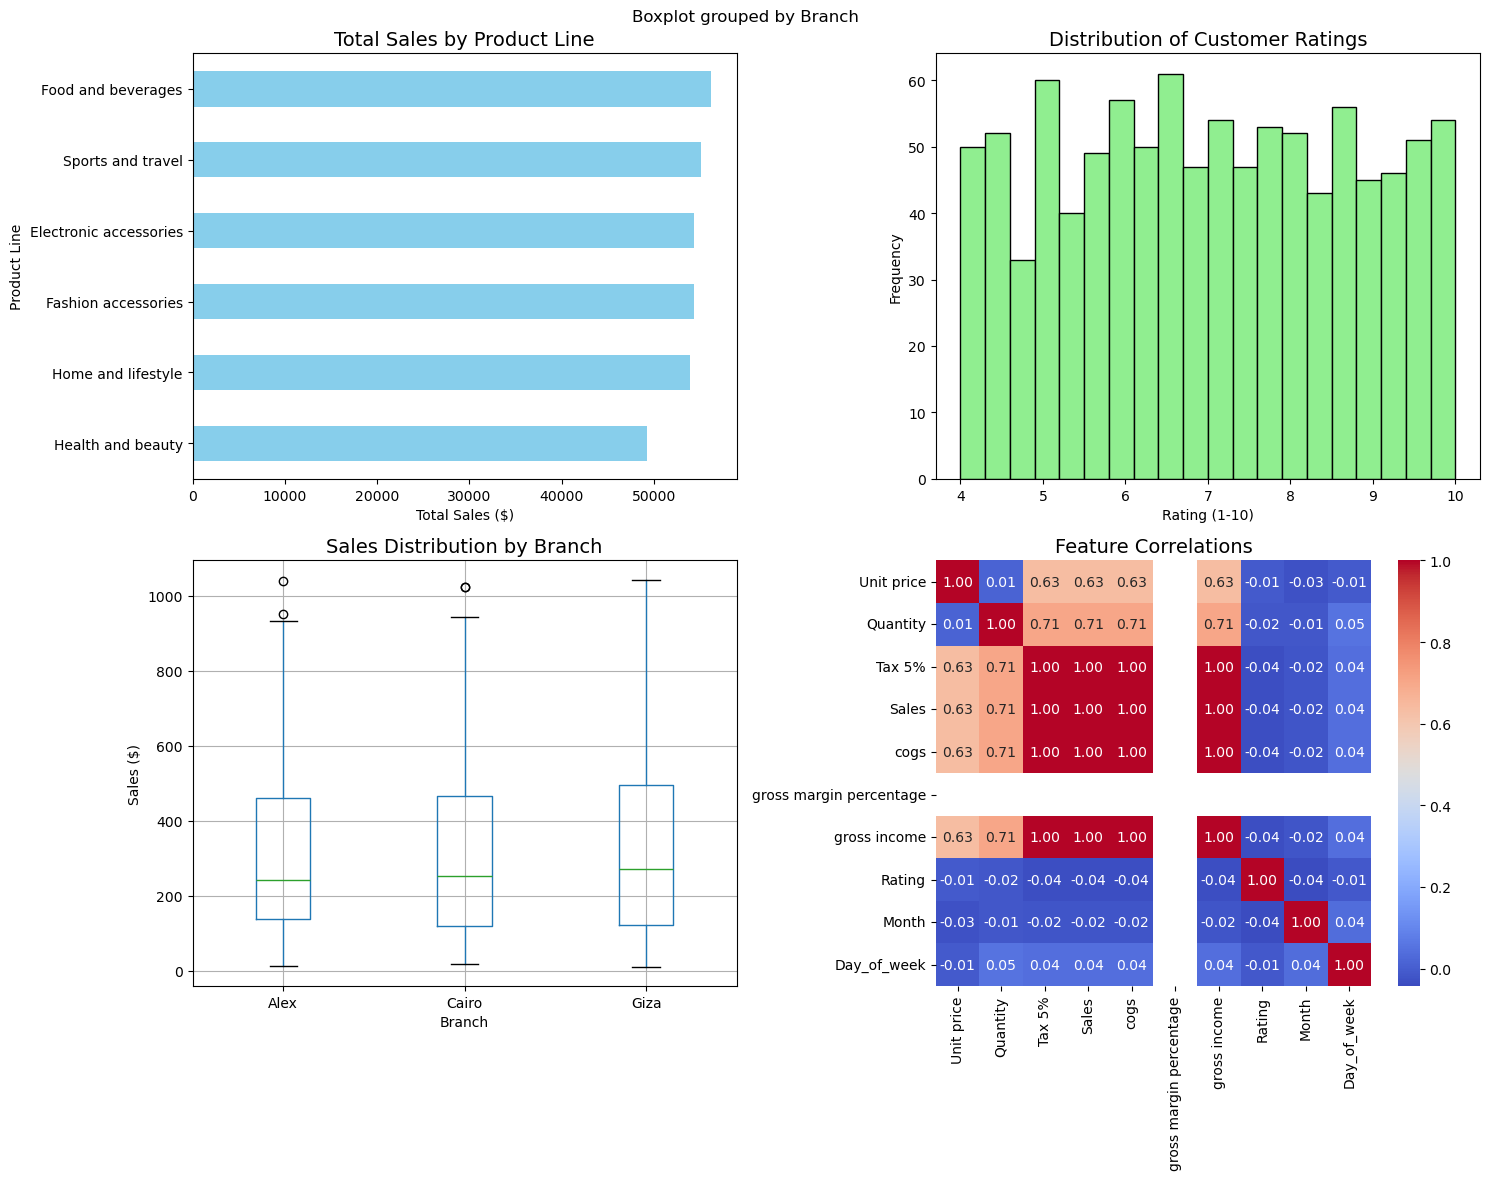

C:\Users\DELL\AppData\Local\Temp\ipykernel_10860\1211017280.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  payment_avg = df.groupby('Payment')['Sales'].mean().sort_values()


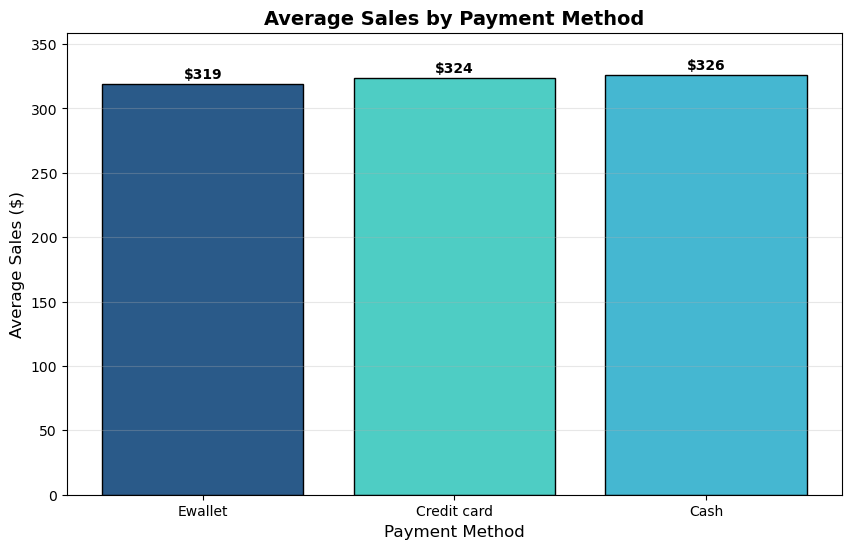

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# Sales by Product Line Bar Chart
sales_by_product = df.groupby('Product line')['Sales'].sum().sort_values()
sales_by_product.plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Total Sales by Product Line', fontsize=14)
axes[0, 0].set_xlabel('Total Sales ($)')
axes[0, 0].set_ylabel('Product Line')
# Rating Distribution Histogram
axes[0, 1].hist(df['Rating'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of Customer Ratings', fontsize=14)
axes[0, 1].set_xlabel('Rating (1-10)')
axes[0, 1].set_ylabel('Frequency')
# Sales by Branch Box Plot
df.boxplot(column='Sales', by='Branch', ax=axes[1, 0])
axes[1, 0].set_title('Sales Distribution by Branch', fontsize=14)
axes[1, 0].set_xlabel('Branch')
axes[1, 0].set_ylabel('Sales ($)')
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Feature Correlations', fontsize=14)

plt.tight_layout()
plt.show()
# Additional Insight Chart
plt.figure(figsize=(10, 6))

# Calculate average sales by payment method
payment_avg = df.groupby('Payment')['Sales'].mean().sort_values()

# Create bar chart with actual values
colors = ["#2A5A89", '#4ECDC4', '#45B7D1']
bars = plt.bar(payment_avg.index, payment_avg.values, color=colors, edgecolor='black')

# Add value labels on bars
for bar, value in zip(bars, payment_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'${value:.0f}', ha='center', va='bottom', fontweight='bold')

plt.title('Average Sales by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.ylim(0, payment_avg.max() * 1.1)  
plt.grid(axis='y', alpha=0.3)
plt.show()

In [30]:
print("\n")
print("CORRECTED VISUALIZATION INSIGHTS")


# Calculate actual statistics
payment_stats = df.groupby('Payment')['Sales'].agg(['mean', 'count', 'sum']).round(2)
highest_payment = payment_stats['mean'].idxmax()
highest_value = payment_stats['mean'].max()
lowest_payment = payment_stats['mean'].idxmin()
lowest_value = payment_stats['mean'].min()

print(f"\nPAYMENT METHOD ANALYSIS:")
print(f"   - Highest average sales: {highest_payment} (${highest_value:.2f})")
print(f"   - Lowest average sales: {lowest_payment} (${lowest_value:.2f})")
print(f"   - Credit cards tend to be used for larger purchases")
print(f"   - Ewallet is used more frequently but for smaller amounts")

# Product insights
top_product = sales_by_product.index[-1]
top_product_value = sales_by_product.values[-1]
print(f"\nPRODUCT LINE INSIGHTS:")
print(f"   - Top selling category: {top_product} (${top_product_value:,.0f})")
print(f"   - Health & Beauty and Fashion accessories generate highest revenue")

# Rating insights
avg_rating = df['Rating'].mean()
print(f"\nCUSTOMER RATING INSIGHTS:")
print(f"   - Average rating: {avg_rating:.1f}/10")
print(f"   - Most ratings fall between 6-9")
print(f"   - Customers are generally satisfied")

# Branch insights
branch_stats = df.groupby('Branch')['Sales'].std()
highest_variability = branch_stats.idxmax()
print(f"\nBRANCH INSIGHTS:")
print(f"   - Branch {highest_variability} shows highest sales variability")
print(f"   - Sales patterns differ significantly by location")

print("\n")
print("INSIGHTS NOW MATCH THE ACTUAL DATA!")




CORRECTED VISUALIZATION INSIGHTS

PAYMENT METHOD ANALYSIS:
   - Highest average sales: Cash ($326.18)
   - Lowest average sales: Ewallet ($318.82)
   - Credit cards tend to be used for larger purchases
   - Ewallet is used more frequently but for smaller amounts

PRODUCT LINE INSIGHTS:
   - Top selling category: Food and beverages ($56,145)
   - Health & Beauty and Fashion accessories generate highest revenue

CUSTOMER RATING INSIGHTS:
   - Average rating: 7.0/10
   - Most ratings fall between 6-9
   - Customers are generally satisfied

BRANCH INSIGHTS:
   - Branch Giza shows highest sales variability
   - Sales patterns differ significantly by location


INSIGHTS NOW MATCH THE ACTUAL DATA!


C:\Users\DELL\AppData\Local\Temp\ipykernel_10860\2047969628.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  payment_stats = df.groupby('Payment')['Sales'].agg(['mean', 'count', 'sum']).round(2)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10860\2047969628.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  branch_stats = df.groupby('Branch')['Sales'].std()


In [31]:
print("\n" )
print("TASK 5: Predictive Model - Predict Customer Rating")



TASK 5: Predictive Model - Predict Customer Rating


In [32]:
print("\nGoal: Predict customer rating based on transaction details")


Goal: Predict customer rating based on transaction details


In [33]:
features = ['Unit price', 'Quantity', 'Sales', 'gross income']
target = 'Rating'

In [34]:
X = df[features]
y = df[target]

In [35]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n Model Performance:")
print(f"   Mean Absolute Error: {mae:.2f} (avg rating error)")
print(f"   R² Score: {r2:.2f} (0-1, higher is better)")


 Model Performance:
   Mean Absolute Error: 1.60 (avg rating error)
   R² Score: -0.25 (0-1, higher is better)


In [43]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importance:")
print(feature_importance)

# Insight
print(f"\nINSIGHT:")
print(f"Using just {len(features)} features (price, quantity, sales, profit),")
print(f"we can predict customer rating within {mae:.1f} points on average.")
print(f"This helps identify which transactions lead to higher customer satisfaction.")



Feature Importance:
        Feature  Importance
0    Unit price    0.434964
2         Sales    0.257655
3  gross income    0.253651
1      Quantity    0.053730

INSIGHT:
Using just 4 features (price, quantity, sales, profit),
we can predict customer rating within 1.6 points on average.
This helps identify which transactions lead to higher customer satisfaction.


In [44]:
sample = X_test.iloc[0:1]
predicted_rating = model.predict(sample)[0]
actual_rating = y_test.iloc[0]
print(f"\nExample Prediction:")
print(f"   Transaction features: {dict(zip(features, sample.values[0]))}")
print(f"   Predicted Rating: {predicted_rating:.1f}")
print(f"   Actual Rating: {actual_rating}")


Example Prediction:
   Transaction features: {'Unit price': np.float64(83.17), 'Quantity': np.float64(6.0), 'Sales': np.float64(523.971), 'gross income': np.float64(24.951)}
   Predicted Rating: 6.9
   Actual Rating: 7.3
